In [2]:
# ============================================================================
# 1. KONFIGURASI & SETUP ENVIRONMENT
# ============================================================================

# IMPOR LIBRARY
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Menonaktifkan peringatan untuk tampilan yang lebih bersih
warnings.filterwarnings('ignore')

# PENGATURAN VISUALISASI (Agar grafik terlihat profesional)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# KONFIGURASI PARAMETER SIMULASI
NUM_SIMULATIONS = 20000  # Jumlah iterasi untuk akurasi statistik
SEED = 42                # Agar hasil konsisten saat dijalankan ulang
np.random.seed(SEED)

# PENYIMPANAN DATA (Placeholder untuk hasil simulasi)
# Nantinya data dari SimPy atau NumPy akan dimasukkan ke sini
df_rekap = pd.DataFrame()

print(f"Konfigurasi Berhasil!")
print(f"Jumlah Simulasi: {NUM_SIMULATIONS}")
print(f"Random Seed: {SEED}")

Konfigurasi Berhasil!
Jumlah Simulasi: 20000
Random Seed: 42


In [3]:
# ============================================================================
# 2. PEMODELAN SISTEM
# ============================================================================

class ProjectStage:
    """Kelas untuk memodelkan tahapan proyek dengan kompleksitas yang lebih realistis"""
    
    def __init__(self, name, base_params, risk_factors=None, dependencies=None):
        """
        Parameters:
        -----------
        name : str
            Nama tahapan
        base_params : dict
            Parameter dasar durasi (optimistic, most_likely, pessimistic)
        risk_factors : dict
            Faktor risiko yang mempengaruhi durasi
        dependencies : list
            Dependensi dengan tahapan lain
        """
        self.name = name
        self.optimistic = base_params['optimistic']
        self.most_likely = base_params['most_likely']
        self.pessimistic = base_params['pessimistic']
        self.risk_factors = risk_factors or {}
        self.dependencies = dependencies or []
        
    def sample_duration(self, n_simulations, risk_multiplier=1.0):
        """
        Sampling durasi dengan mempertimbangkan distribusi dan faktor risiko
        """
        # Distribusi triangular untuk estimasi tiga titik (PERT Distribution)
        base_duration = np.random.triangular(
            self.optimistic,
            self.most_likely,
            self.pessimistic,
            n_simulations
        )
        
        # Aplikasi faktor risiko
        for risk_name, risk_params in self.risk_factors.items():
            if risk_params['type'] == 'discrete':
                # Risiko diskrit (misal: bug critical, perubahan requirement)
                probability = risk_params['probability']
                impact = risk_params['impact']
                
                # Generate kejadian risiko (Bernoulli trial)
                risk_occurs = np.random.random(n_simulations) < probability
                
                # Aplikasi impact jika risiko terjadi
                base_duration = np.where(
                    risk_occurs,
                    base_duration * (1 + impact),
                    base_duration
                )
                
            elif risk_params['type'] == 'continuous':
                # Risiko kontinu (misal: variasi produktivitas tim)
                mean = risk_params['mean']
                std = risk_params['std']
                
                # Sampling dari distribusi normal
                productivity_factor = np.random.normal(mean, std, n_simulations)
                # Clip digunakan untuk membatasi nilai yang tidak masuk akal (extreme outliers)
                base_duration = base_duration / np.clip(productivity_factor, 0.5, 1.5)
        
        return base_duration * risk_multiplier

# Info: Kelas ini akan digunakan untuk mendefinisikan objek tahapan proyek (SDLC)
# pada bagian Inisialisasi Data nanti.
print(f"Model sistem '{ProjectStage.__name__}' telah didefinisikan.")

Model sistem 'ProjectStage' telah didefinisikan.


In [4]:
# ============================================================================
# 3. DEFINISI TAHAPAN PROYEK
# ============================================================================

# Konfigurasi tahapan dengan faktor risiko
# Struktur: optimistic (tercepat), most_likely (paling mungkin), pessimistic (terlama)
project_stages_config = {
    "Analisis_Kebutuhan": {
        "base_params": {"optimistic": 4, "most_likely": 6, "pessimistic": 9},
        "risk_factors": {
            "perubahan_requirement": {
                "type": "discrete",
                "probability": 0.3,
                "impact": 0.25  # +25% durasi jika terjadi
            },
            "klarity_requirement": {
                "type": "continuous",
                "mean": 1.0,
                "std": 0.2
            }
        }
    },
    "Desain_Arsitektur": {
        "base_params": {"optimistic": 5, "most_likely": 8, "pessimistic": 12},
        "risk_factors": {
            "review_iteration": {
                "type": "discrete",
                "probability": 0.4,
                "impact": 0.15
            }
        },
        "dependencies": ["Analisis_Kebutuhan"]
    },
    "Implementasi_Frontend": {
        "base_params": {"optimistic": 10, "most_likely": 15, "pessimistic": 22},
        "risk_factors": {
            "bug_complexity": {
                "type": "continuous",
                "mean": 1.0,
                "std": 0.25
            },
            "dependensi_library": {
                "type": "discrete",
                "probability": 0.2,
                "impact": 0.1
            }
        },
        "dependencies": ["Desain_Arsitektur"]
    },
    "Implementasi_Backend": {
        "base_params": {"optimistic": 12, "most_likely": 18, "pessimistic": 28},
        "risk_factors": {
            "api_complexity": {
                "type": "continuous",
                "mean": 1.0,
                "std": 0.3
            },
            "integration_issues": {
                "type": "discrete",
                "probability": 0.25,
                "impact": 0.2
            }
        },
        "dependencies": ["Desain_Arsitektur"]
    },
    "Pengujian_Integrasi": {
        "base_params": {"optimistic": 5, "most_likely": 8, "pessimistic": 14},
        "risk_factors": {
            "bug_discovery_rate": {
                "type": "continuous",
                "mean": 1.0,
                "std": 0.3
            },
            "critical_bugs": {
                "type": "discrete",
                "probability": 0.15,
                "impact": 0.4  # +40% jika ada bug critical
            }
        },
        "dependencies": ["Implementasi_Frontend", "Implementasi_Backend"]
    },
    "Deployment_Produksi": {
        "base_params": {"optimistic": 2, "most_likely": 3, "pessimistic": 6},
        "risk_factors": {
            "server_issues": {
                "type": "discrete",
                "probability": 0.1,
                "impact": 0.5
            },
            "rollback_needed": {
                "type": "discrete",
                "probability": 0.05,
                "impact": 0.8  # +80% jika perlu rollback
            }
        },
        "dependencies": ["Pengujian_Integrasi"]
    }
}

print("Konfigurasi tahapan proyek berhasil dimuat.")
print(f"Total tahapan yang didefinisikan: {len(project_stages_config)}")

Konfigurasi tahapan proyek berhasil dimuat.
Total tahapan yang didefinisikan: 6


In [5]:
# ============================================================================
# 4. SIMULATOR MONTE CARLO
# ============================================================================

class MonteCarloProjectSimulation:
    """Kelas untuk menjalankan simulasi Monte Carlo yang lebih kompleks"""
    
    def __init__(self, stages_config, num_simulations=10000):
        self.stages_config = stages_config
        self.num_simulations = num_simulations
        self.stages = {}
        self.simulation_results = None
        self.initialize_stages()
        
    def initialize_stages(self):
        """Inisialisasi objek tahapan dari konfigurasi"""
        for stage_name, config in self.stages_config.items():
            self.stages[stage_name] = ProjectStage(
                name=stage_name,
                base_params=config['base_params'],
                risk_factors=config.get('risk_factors', {}),
                dependencies=config.get('dependencies', [])
            )
    
    def run_simulation(self):
        """Menjalankan simulasi Monte Carlo lengkap"""
        results = pd.DataFrame(index=range(self.num_simulations))
        
        # 1. Simulasi durasi per tahapan (Sampling)
        for stage_name, stage in self.stages.items():
            results[stage_name] = stage.sample_duration(self.num_simulations)
        
        # 2. Simulasi ketergantungan antar tahapan (Logic Timing)
        start_times = pd.DataFrame(index=range(self.num_simulations))
        end_times = pd.DataFrame(index=range(self.num_simulations))
        
        for stage_name in self.stages.keys():
            deps = self.stages[stage_name].dependencies
            
            if not deps:
                # Tahap awal: mulai dari hari 0
                start_times[stage_name] = 0
            else:
                # Mulai setelah SEMUA dependensi (pendahulu) selesai
                start_times[stage_name] = end_times[deps].max(axis=1)
            
            # Waktu selesai = waktu mulai + durasi sampling
            end_times[stage_name] = start_times[stage_name] + results[stage_name]
        
        # 3. Hitung durasi total proyek (Finish time tahap terakhir)
        results['Total_Duration'] = end_times.max(axis=1)
        
        # Simpan metadata waktu per tahapan untuk analisis lebih lanjut
        for stage_name in self.stages.keys():
            results[f'{stage_name}_Start'] = start_times[stage_name]
            results[f'{stage_name}_Finish'] = end_times[stage_name]
        
        self.simulation_results = results
        return results
    
    def calculate_critical_path_probability(self):
        """Menghitung seberapa sering sebuah tahapan menjadi penentu durasi proyek"""
        if self.simulation_results is None:
            raise ValueError("Jalankan simulasi terlebih dahulu (run_simulation)")
        
        critical_path_probs = {}
        total_duration = self.simulation_results['Total_Duration']
        
        for stage_name in self.stages.keys():
            stage_finish = self.simulation_results[f'{stage_name}_Finish']
            
            # Korelasi antara durasi tahap X dengan total durasi proyek
            correlation = self.simulation_results[stage_name].corr(total_duration)
            
            # Identifikasi apakah tahapan ini selesai bersamaan dengan selesainya proyek
            # Jika ya, berarti ia berada di jalur kritis pada iterasi tersebut
            is_critical = (stage_finish + 0.001) >= total_duration
            prob_critical = np.mean(is_critical)
            
            critical_path_probs[stage_name] = {
                'probability_critical': prob_critical,
                'correlation_to_total': correlation,
                'avg_duration': self.simulation_results[stage_name].mean()
            }
        
        return pd.DataFrame(critical_path_probs).T
    
    def analyze_risk_contribution(self):
        """Analisis kontribusi variansi tiap tahapan terhadap ketidakpastian proyek"""
        if self.simulation_results is None:
            raise ValueError("Jalankan simulasi terlebih dahulu")
        
        total_var = self.simulation_results['Total_Duration'].var()
        contributions = {}
        
        for stage_name in self.stages.keys():
            stage_var = self.simulation_results[stage_name].var()
            # Kovariansi menunjukkan seberapa erat pergerakan durasi tahap dengan total durasi
            stage_covar = self.simulation_results[stage_name].cov(
                self.simulation_results['Total_Duration']
            )
            
            # Proporsi kontribusi terhadap variansi total proyek
            contribution_pct = (stage_covar / total_var) * 100
            
            contributions[stage_name] = {
                'variance': stage_var,
                'contribution_percent': contribution_pct,
                'std_dev': np.sqrt(stage_var)
            }
        
        return pd.DataFrame(contributions).T

print("Simulator Monte Carlo telah siap digunakan.")


Simulator Monte Carlo telah siap digunakan.


In [6]:
# ============================================================================
# 5. MENJALANKAN SIMULASI
# ============================================================================

# Inisialisasi simulator dengan konfigurasi yang telah dibuat
simulator = MonteCarloProjectSimulation(
    stages_config=project_stages_config,
    num_simulations=NUM_SIMULATIONS
)

# Menjalankan proses sampling dan perhitungan durasi
results = simulator.run_simulation()

# Menampilkan 5 sampel teratas dari hasil simulasi
print(f"Simulasi selesai dijalankan untuk {NUM_SIMULATIONS} iterasi.")
print("-" * 30)
display(results.head())

# Menampilkan statistik deskriptif awal untuk Total Durasi
print("\nRingkasan Statistik Total Durasi Proyek:")
print(results['Total_Duration'].describe(percentiles=[.1, .5, .9]))

Simulasi selesai dijalankan untuk 20000 iterasi.
------------------------------


,Analisis_Kebutuhan,Desain_Arsitektur,Implementasi_Frontend,Implementasi_Backend,Pengujian_Integrasi,Deployment_Produksi,Total_Duration,Analisis_Kebutuhan_Start,Analisis_Kebutuhan_Finish,Desain_Arsitektur_Start,Desain_Arsitektur_Finish,Implementasi_Frontend_Start,Implementasi_Frontend_Finish,Implementasi_Backend_Start,Implementasi_Backend_Finish,Pengujian_Integrasi_Start,Pengujian_Integrasi_Finish,Deployment_Produksi_Start,Deployment_Produksi_Finish
0,6.694505,10.073158,16.765734,26.073809,10.797450,3.322722,56.961644,0,6.694505,6.694505,16.767663,16.767663,33.533397,16.767663,42.841473,42.841473,53.638922,53.638922,56.961644
1,10.782072,8.047565,11.508466,19.811623,14.625030,4.498336,57.764627,0,10.782072,10.782072,18.829637,18.829637,30.338103,18.829637,38.641261,38.641261,53.266291,53.266291,57.764627
2,7.241309,6.811856,11.582119,35.480887,18.772849,5.220934,73.527835,0,7.241309,7.241309,14.053165,14.053165,25.635284,14.053165,49.534052,49.534052,68.306901,68.306901,73.527835
3,6.817769,8.014502,17.185758,11.944570,9.663449,3.704489,45.385967,0,6.817769,6.817769,14.832271,14.832271,32.018030,14.832271,26.776841,32.018030,41.681479,41.681479,45.385967
4,6.026373,11.680383,24.042991,25.799153,9.386188,3.117813,56.009911,0,6.026373,6.026373,17.706756,17.706756,41.749747,17.706756,43.505910,43.505910,52.892097,52.892097,56.009911



Ringkasan Statistik Total Durasi Proyek:
count    20000.000000
mean        54.172655
std          9.443800
min         32.384644
10%         43.379651
50%         52.802197
90%         66.848511
max        106.704167
Name: Total_Duration, dtype: float64


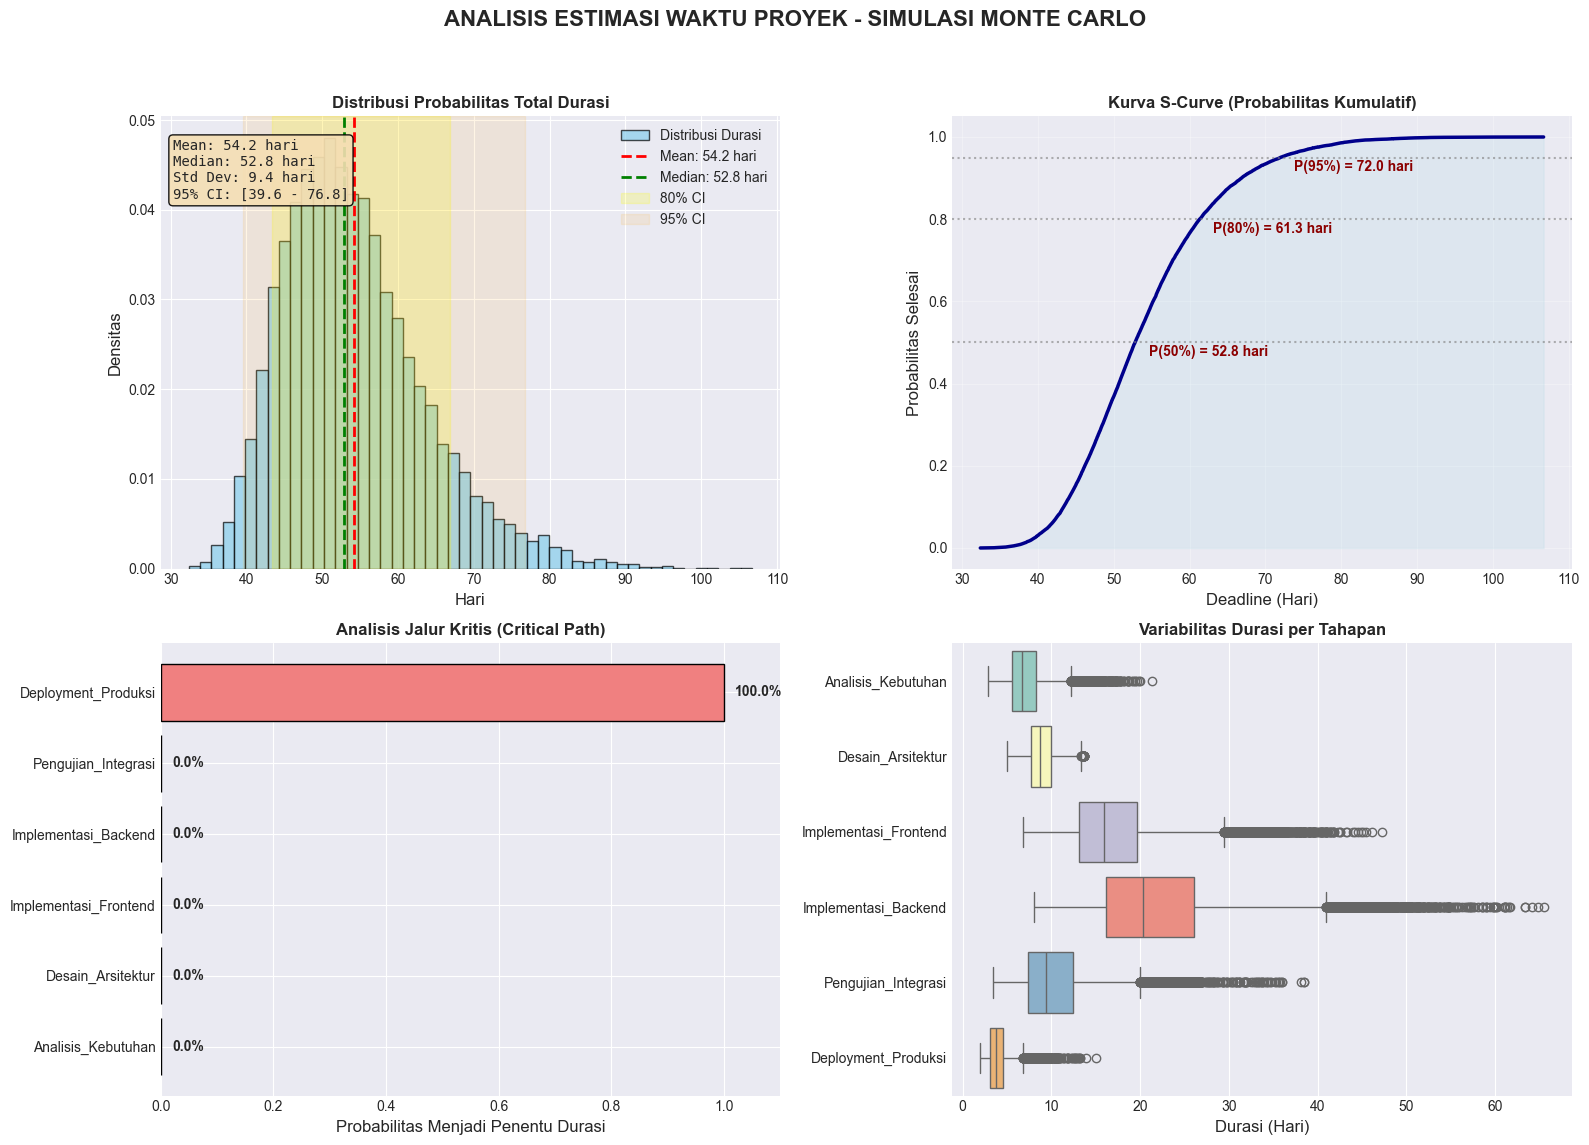

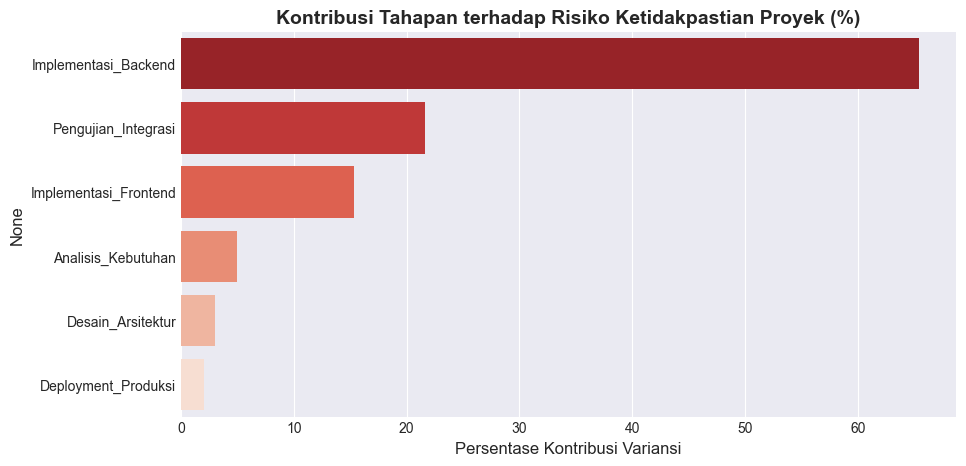

In [7]:
# ============================================================================
# 6. VISUALISASI & ANALISIS HASIL
# ============================================================================

# Setup figure untuk 2 baris x 2 kolom (4 Plot Utama)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ANALISIS ESTIMASI WAKTU PROYEK - SIMULASI MONTE CARLO', 
             fontsize=16, fontweight='bold', y=0.98)

# --- PLOT 1: Distribusi Durasi Total Proyek (Kiri Atas) ---
ax1 = axes[0, 0]
ax1.hist(results['Total_Duration'], bins=50, edgecolor='black', alpha=0.7, 
         density=True, color='skyblue', label='Distribusi Durasi')

# Tambahkan garis mean dan median
mean_duration = results['Total_Duration'].mean()
median_duration = np.median(results['Total_Duration'])
ax1.axvline(mean_duration, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_duration:.1f} hari')
ax1.axvline(median_duration, color='green', linestyle='--', linewidth=2, 
            label=f'Median: {median_duration:.1f} hari')

# Tambahkan confidence intervals (CI)
ci_80 = np.percentile(results['Total_Duration'], [10, 90])
ci_95 = np.percentile(results['Total_Duration'], [2.5, 97.5])
ax1.axvspan(ci_80[0], ci_80[1], alpha=0.2, color='yellow', label='80% CI')
ax1.axvspan(ci_95[0], ci_95[1], alpha=0.1, color='orange', label='95% CI')

# Box Statistik Utama
stats_text = f"Mean: {mean_duration:.1f} hari\nMedian: {median_duration:.1f} hari\nStd Dev: {results['Total_Duration'].std():.1f} hari\n95% CI: [{ci_95[0]:.1f} - {ci_95[1]:.1f}]"
props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax1.text(0.02, 0.95, stats_text, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', bbox=props, fontfamily='monospace')

ax1.set_title('Distribusi Probabilitas Total Durasi', fontsize=12, fontweight='bold')
ax1.set_xlabel('Hari'), ax1.set_ylabel('Densitas')
ax1.legend(loc='upper right')

# --- PLOT 2: Kurva Probabilitas Selesai (Kanan Atas) ---
ax2 = axes[0, 1]
deadlines = np.sort(results['Total_Duration'])
probs = np.arange(1, len(deadlines) + 1) / len(deadlines)

ax2.plot(deadlines, probs, linewidth=2.5, color='darkblue')
ax2.fill_between(deadlines, probs, alpha=0.2, color='lightblue')

# Tandai titik probabilitas penting
for p in [0.5, 0.8, 0.95]:
    val = np.percentile(results['Total_Duration'], p*100)
    ax2.axhline(p, color='gray', linestyle=':', alpha=0.6)
    ax2.annotate(f'P({p*100:.0f}%) = {val:.1f} hari', (val, p), xytext=(10, -10), 
                 textcoords='offset points', fontweight='bold', color='darkred')

ax2.set_title('Kurva S-Curve (Probabilitas Kumulatif)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Deadline (Hari)'), ax2.set_ylabel('Probabilitas Selesai')
ax2.grid(True, alpha=0.3)

# --- PLOT 3: Analisis Jalur Kritis (Kiri Bawah) ---
ax3 = axes[1, 0]
critical_df = simulator.calculate_critical_path_probability().sort_values('probability_critical')
bars = ax3.barh(critical_df.index, critical_df['probability_critical'], color='lightcoral', edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax3.text(width + 0.02, bar.get_y() + bar.get_height()/2, f'{width:.1%}', va='center', fontweight='bold')

ax3.set_title('Analisis Jalur Kritis (Critical Path)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Probabilitas Menjadi Penentu Durasi')
ax3.set_xlim(0, 1.1)

# --- PLOT 4: Distribusi per Tahapan (Kanan Bawah) ---
ax4 = axes[1, 1]
stage_cols = list(project_stages_config.keys())
sns.boxplot(data=results[stage_cols], orient='h', ax=ax4, palette='Set3')
ax4.set_title('Variabilitas Durasi per Tahapan', fontsize=12, fontweight='bold')
ax4.set_xlabel('Durasi (Hari)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- PLOT TAMBAHAN: Analisis Kontribusi Risiko ---
plt.figure(figsize=(10, 5))
risk_contrib = simulator.analyze_risk_contribution().sort_values('contribution_percent', ascending=False)
sns.barplot(x=risk_contrib['contribution_percent'], y=risk_contrib.index, palette='Reds_r')
plt.title('Kontribusi Tahapan terhadap Risiko Ketidakpastian Proyek (%)', fontweight='bold')
plt.xlabel('Persentase Kontribusi Variansi')
plt.show()

In [8]:
# ============================================================================
# 7. ANALISIS STATISTIK & LAPORAN MANAJERIAL
# ============================================================================

print("\n" + "=" * 70)
print("             LAPORAN ANALISIS STATISTIK PROYEK (MONTE CARLO)             ")
print("=" * 70)

# 1. Statistik Deskriptif Utama
total_duration = results['Total_Duration']
mean_val = total_duration.mean()
std_val = total_duration.std()

print(f"\n[1] RINGKASAN DURASI TOTAL PROYEK:")
print(f"• Rata-rata (Expected): {mean_val:.1f} hari")
print(f"• Median (P50)        : {np.median(total_duration):.1f} hari")
print(f"• Standar Deviasi    : {std_val:.1f} hari")
print(f"• Rentang Durasi      : {total_duration.min():.1f} s/d {total_duration.max():.1f} hari")

# 2. Confidence Intervals (Estimasi Rentang)
print(f"\n[2] ESTIMASI RENTANG KEPERCAYAAN (CONFIDENCE INTERVALS):")
print(f"• 80% CI (P10 - P90)  : [{np.percentile(total_duration, 10):.1f}, {np.percentile(total_duration, 90):.1f}] hari")
print(f"• 90% CI (P5 - P95)   : [{np.percentile(total_duration, 5):.1f}, {np.percentile(total_duration, 95):.1f}] hari")
print(f"• 95% CI (P2.5 - P97.5): [{np.percentile(total_duration, 2.5):.1f}, {np.percentile(total_duration, 97.5):.1f}] hari")

# 3. Analisis Probabilitas Terhadap Deadline
print(f"\n[3] ANALISIS PROBABILITAS TERHADAP TARGET (DEADLINE):")
deadline_scenarios = [60, 65, 70, 75, 80]

for dl in deadline_scenarios:
    prob_on_time = np.mean(total_duration <= dl)
    prob_late = 1 - prob_on_time
    # Menghitung potensi keterlambatan pada skenario terburuk (P95)
    worst_case = np.percentile(total_duration, 95)
    days_at_risk = max(0, worst_case - dl)
    
    status = "AMAN" if prob_on_time > 0.8 else "BERISIKO"
    
    print(f"Target {dl} Hari:")
    print(f"  • Probabilitas On-Time: {prob_on_time:.1%} [{status}]")
    print(f"  • Probabilitas Terlambat: {prob_late:.1%}")
    print(f"  • Potensi Keterlambatan (Worst Case P95): {days_at_risk:.1f} hari")

# 4. Analisis Jalur Kritis (Critical Path)
print(f"\n[4] ANALISIS TAHAPAN PALING KRITIS (SENSITIVITAS):")
critical_probs = simulator.calculate_critical_path_probability()
# Mengurutkan berdasarkan probabilitas tertinggi
for stage, data in critical_probs.sort_values('probability_critical', ascending=False).iterrows():
    print(f"  • {stage:22}: {data['probability_critical']:6.1%} kemungkinan menjadi penghambat utama")

# 5. Rekomendasi Mitigasi & Buffer
print(f"\n[5] REKOMENDASI CADANGAN WAKTU (BUFFER):")
# Buffer dihitung dari selisih percentile tertentu dengan rata-rata
safety_buffer = np.percentile(total_duration, 80) - mean_val
contingency_reserve = np.percentile(total_duration, 95) - mean_val

print(f"• Safety Buffer (80% Confidence)    : {safety_buffer:4.1f} hari")
print(f"• Contingency Reserve (95% Conf.)   : {contingency_reserve:4.1f} hari")
print(f"• Rekomendasi Jadwal yang Dijanjikan: {mean_val + safety_buffer:4.1f} hari")

print("\n" + "=" * 70)


             LAPORAN ANALISIS STATISTIK PROYEK (MONTE CARLO)             

[1] RINGKASAN DURASI TOTAL PROYEK:
• Rata-rata (Expected): 54.2 hari
• Median (P50)        : 52.8 hari
• Standar Deviasi    : 9.4 hari
• Rentang Durasi      : 32.4 s/d 106.7 hari

[2] ESTIMASI RENTANG KEPERCAYAAN (CONFIDENCE INTERVALS):
• 80% CI (P10 - P90)  : [43.4, 66.8] hari
• 90% CI (P5 - P95)   : [41.3, 72.0] hari
• 95% CI (P2.5 - P97.5): [39.6, 76.8] hari

[3] ANALISIS PROBABILITAS TERHADAP TARGET (DEADLINE):
Target 60 Hari:
  • Probabilitas On-Time: 76.6% [BERISIKO]
  • Probabilitas Terlambat: 23.4%
  • Potensi Keterlambatan (Worst Case P95): 12.0 hari
Target 65 Hari:
  • Probabilitas On-Time: 87.4% [AMAN]
  • Probabilitas Terlambat: 12.6%
  • Potensi Keterlambatan (Worst Case P95): 7.0 hari
Target 70 Hari:
  • Probabilitas On-Time: 93.4% [AMAN]
  • Probabilitas Terlambat: 6.6%
  • Potensi Keterlambatan (Worst Case P95): 2.0 hari
Target 75 Hari:
  • Probabilitas On-Time: 96.7% [AMAN]
  • Probabilitas Ter

In [ ]:
# ============================================================================
# 8. ANALISIS SENSITIVITAS & OPTIMASI RESOURCE
# ============================================================================

class ResourceOptimizationAnalyzer:
    """Kelas untuk menganalisis dampak penambahan resource terhadap proyek"""
    
    def __init__(self, simulation_results, project_stages):
        self.results = simulation_results
        self.stages = project_stages
        # Definisi biaya per hari dan potensi peningkatan produktivitas
        self.resource_costs = {
            'developer': {'cost_per_day': 1500000, 'productivity_gain': 0.3},
            'tester': {'cost_per_day': 1200000, 'productivity_gain': 0.25},
            'analyst': {'cost_per_day': 1800000, 'productivity_gain': 0.2},
            'devops': {'cost_per_day': 2000000, 'productivity_gain': 0.35},
            'senior_developer': {'cost_per_day': 2500000, 'productivity_gain': 0.4}
        }
    
    def calculate_resource_impact(self, stage_name, resource_type, quantity, duration_days):
        """Menghitung ROI dan dampak durasi dari penambahan resource"""
        resource_params = self.resource_costs[resource_type]
        
        # Law of diminishing returns (penambahan resource tidak linear sempurna)
        improvement_factor = 1 - (resource_params['productivity_gain'] * min(quantity / 3, 1))
        
        # Simulasi ulang dengan durasi tahap yang dipersingkat
        scenario_results = self.results.copy()
        scenario_results[stage_name] = scenario_results[stage_name] * improvement_factor
        
        # Recalculate total project duration dengan dependency logic
        scenario_totals = []
        for idx in range(len(self.results)):
            stage_times = {}
            for curr_stage in self.stages.keys():
                deps = self.stages[curr_stage].dependencies
                start_time = max([stage_times.get(d, 0) for d in deps]) if deps else 0
                
                # Gunakan durasi baru jika ini adalah tahap yang dioptimasi
                duration = scenario_results.loc[idx, curr_stage] if curr_stage == stage_name else self.results.loc[idx, curr_stage]
                stage_times[curr_stage] = start_time + duration
            
            scenario_totals.append(max(stage_times.values()))
        
        # Hitung Metrik Finansial
        baseline_mean = self.results['Total_Duration'].mean()
        optimized_mean = np.mean(scenario_totals)
        reduction = baseline_mean - optimized_mean
        
        total_cost = resource_params['cost_per_day'] * quantity * duration_days
        project_cost_per_day = 10000000 # Asumsi overhead proyek per hari
        savings = reduction * project_cost_per_day
        roi = ((savings - total_cost) / total_cost) * 100 if total_cost > 0 else 0
        
        return {
            'stage': stage_name, 'resource_type': resource_type, 'quantity': quantity,
            'duration_reduction': reduction, 'roi': roi, 'total_cost': total_cost,
            'optimized_mean': optimized_mean, 'net_benefit': savings - total_cost
        }

    def analyze_multiple_scenarios(self, scenarios):
        return [self.calculate_resource_impact(s['stage'], s['resource_type'], s['quantity'], s['duration_days']) for s in scenarios]

# --- Eksekusi Analisis ---
analyzer = ResourceOptimizationAnalyzer(results, simulator.stages)
optimization_scenarios = [
    {'stage': 'Implementasi_Backend', 'resource_type': 'senior_developer', 'quantity': 2, 'duration_days': 20},
    {'stage': 'Pengujian_Integrasi', 'resource_type': 'tester', 'quantity': 2, 'duration_days': 15},
    {'stage': 'Analisis_Kebutuhan', 'resource_type': 'analyst', 'quantity': 2, 'duration_days': 8},
    {'stage': 'Deployment_Produksi', 'resource_type': 'devops', 'quantity': 2, 'duration_days': 5}
]

sc_results = analyzer.analyze_multiple_scenarios(optimization_scenarios)

# --- Visualisasi Dampak ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Pengurangan Durasi
names = [f"{r['stage']}\n({r['quantity']} {r['resource_type']})" for r in sc_results]
reductions = [r['duration_reduction'] for r in sc_results]
ax1.barh(names, reductions, color='teal')
ax1.set_title('Pengurangan Durasi Proyek (Hari)', fontweight='bold')
ax1.grid(axis='x', linestyle='--', alpha=0.6)

# Plot 2: ROI
rois = [r['roi'] for r in sc_results]
ax2.bar(range(len(names)), rois, color=['green' if x > 0 else 'red' for x in rois])
ax2.set_xticks(range(len(names)))
ax2.set_xticklabels([f"S{i+1}" for i in range(len(names))])
ax2.set_title('Return on Investment (%)', fontweight='bold')
ax2.axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

# --- Laporan Rekomendasi ---
print("\n" + "="*70)
print("REKOMENDASI STRATEGIS OPTIMASI")
print("="*70)
for i, r in enumerate(sc_results, 1):
    print(f"S{i}. {r['stage']}: Potensi percepatan {r['duration_reduction']:.1f} hari | ROI: {r['roi']:.1f}%")